<a href="https://colab.research.google.com/github/deepan98raj-dotcom/git_notes_/blob/main/Session_35_LSTM_and_BILstm_Codes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Over view of LSTM and BILSTM

### LSTMs and BiLSTMs are specialized types of Recurrent Neural Networks (RNNs) designed to process sequential data like text, time-series, and audio.

There are three basic algorithms/architectures in RNN:

* Standard RNN (Vanilla RNN): Has memory, but it is strictly short-term.
* LSTM (Long Short-Term Memory): An upgrade featuring long-term memory.
* GRU (Gated Recurrent Unit): Similar to LSTM, but a slightly faster-working version.

The BiLSTM you mentioned is a mechanism that makes this LSTM even more powerful. Let's break it down easily.
## LSTM vs BiLSTM: What is the difference?
The main difference between a normal LSTM and a Bidirectional LSTM is this:
## 1. LSTM (Unidirectional)
This reads data in only one direction. That means it only processes from left-to-right (past to future).

* Example: "Last night I ______."
* Mechanism: It must predict the next word (e.g., "slept") based solely on the preceding words ("Last night I"). This is how a normal LSTM works.

## 2. BiLSTM (Bidirectional)
This reads data in both directions! Left-to-right (Past to Future) and Right-to-left (Future to Past). It collects information from both sides to make a central decision.

* Example: "I didn't sleep ______ night, so now I feel sleepy."
* Mechanism: To fill this blank space, looking only at the preceding word "I" is not enough. The succeeding words like "night, so now I feel sleepy" are also required. BiLSTM reads from the front and from the back, concluding:  'I' is at the front, and 'night' is at the back... so 'last' must belong in the middle!" It predicts it perfectly.

## Summary

* RNN Types: Vanilla RNN $\rightarrow$ LSTM $\rightarrow$ GRU
* Processing Direction Types:
* Unidirectional (One side): Regular LSTM / Regular GRU
   * Bidirectional (Both sides): BiLSTM / BiGRU

BiLSTM is primarily used where the full context of the entire sentence must be under control, such as in Language Translation (like Google Translate) and Named Entity Recognition (NER).



**Following is the  technical explanation of LSTMs and BiLSTMs.**

------------------------------
## Step 5: Solving the Flaw – The LSTM Architecture (Long Short-Term Memory)
To fix the vanishing gradient problem of Standard RNNs, the LSTM has been introduced  that allows information to flow across dozens of time steps completely untouched.
## 1. The Core Innovation: The Cell State ($C_t$)
Instead of having just one hidden state ($h_t$), an LSTM tracks two distinct states at every time step:

* Hidden State ($h_t$): The short-term memory, used to generate the immediate output.
* Cell State ($C_t$): The long-term memory highway. It runs straight down the entire chain with only minor linear interactions, preventing gradients from shrinking to zero.

## 2. The Internal Regulators: Gates
An LSTM regulates what goes onto and stays on this long-term highway using three mathematical filters called Gates. Every gate uses a sigmoid activation function (which outputs numbers between 0 and 1, where 0 means "block completely" and 1 means "let everything pass").

* Forget Gate ($f_t$): Decides what to throw away from the long-term memory.
* Example: If a paragraph transitions from talking about a boy to a girl, this gate deletes the old gender context.
* Input Gate ($i_t$): Decides what new information from the current word is worth saving to the long-term memory.
* Output Gate ($o_t$): Decides what the next short-term hidden state ($h_t$) should be, based on the newly updated long-term memory.

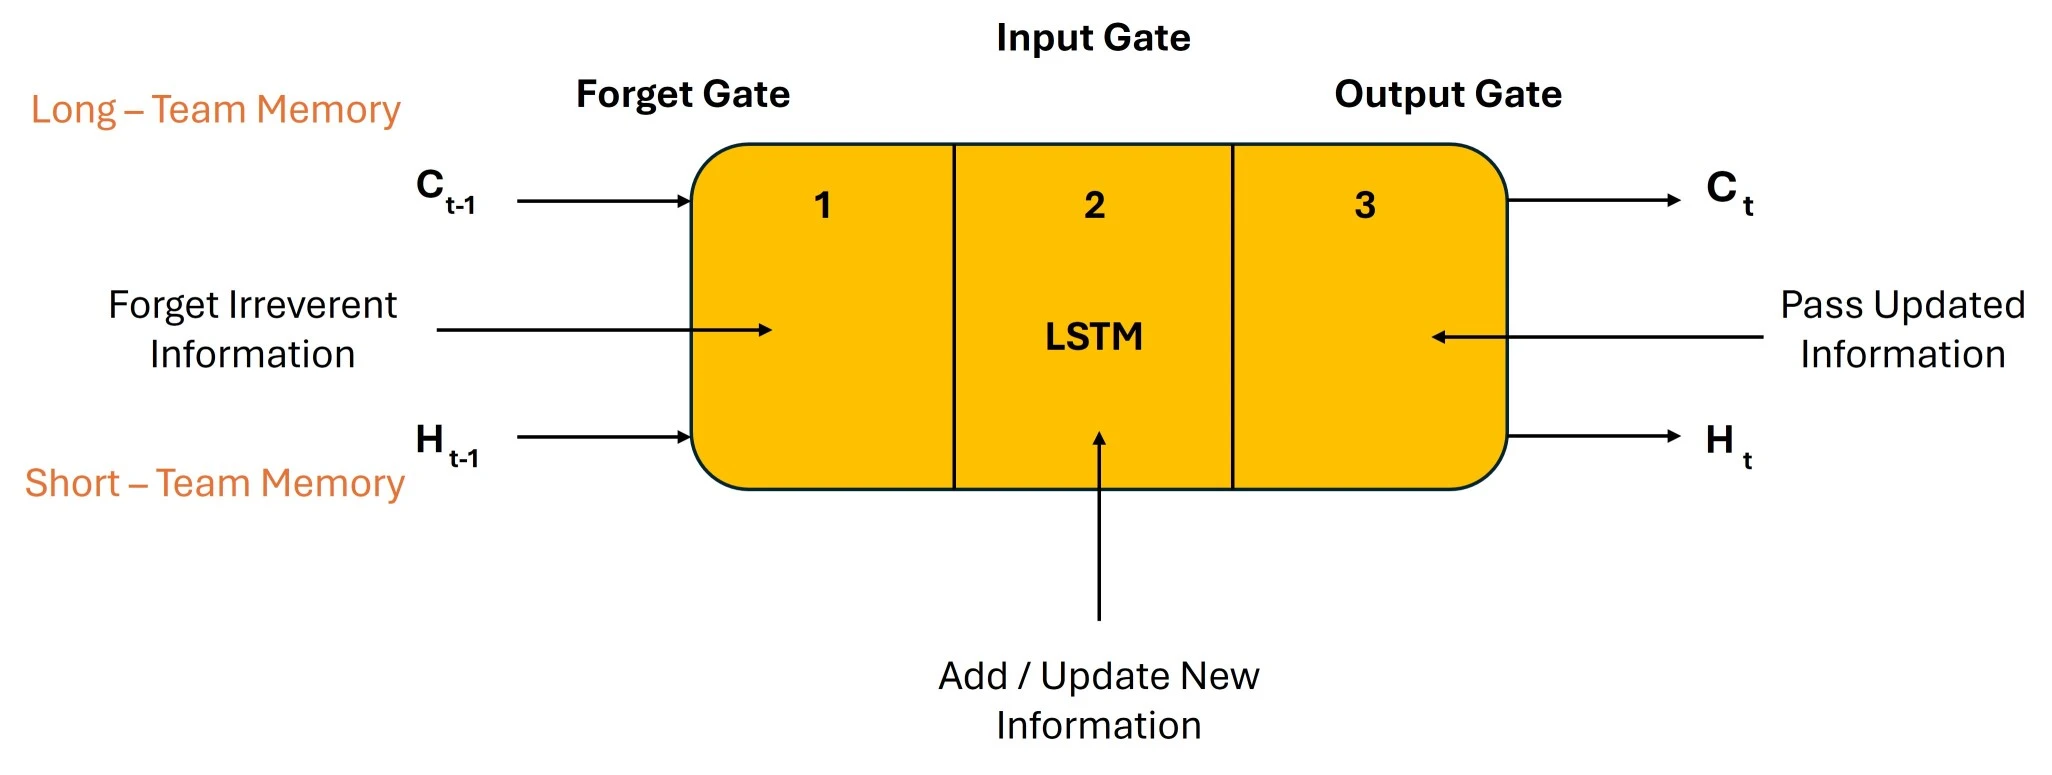



------------------------------
## Step 7: Maximizing Context – The BiLSTM Architecture (Bidirectional LSTM)
While an LSTM fixes the memory loss problem, it is still strictly unidirectional. It processes text linearly from left to right. This creates a final structural limitation: the model has no idea what happens in the future of the sequence.


**The Context Flaw**:


In the sentence: "The bank of the river was muddy."
When a unidirectional LSTM processes the word "bank", it only knows the word "The". It cannot distinguish whether "bank" means a financial institution or a riverbank until it moves forward.

**The Solution: Two Streams**

A BiLSTM duplicates the LSTM structure to look at the sequence from both angles simultaneously:

* Forward LSTM Layer: Reads the text normally from Left-to-Right (t=1 → t=T).
* Backward LSTM Layer: Reads the exact same text completely in reverse, from Right-to-Left (t=T → t=1).

**The Concatenation:**

At every single time step, the model takes the hidden state from the forward pass ($h_{t\_forward}$) and the hidden state from the backward pass ($h_{t\_backward}$) and stitches them together (concatenation).

**$$\text{Final Hidden State } (h_t) = [h_{t\_forward} \ ; \ h_{t\_backward}]$$**

This gives the final output layer a complete, 360-degree understanding of both what came before the word and what comes after it.

------------------------------
## Summary Comparison Matrix

| Model Architecture | Processing Direction | Memory Track Type | Core Strength | Fatal Vulnerability |
|---|---|---|---|---|
| Standard RNN | Unidirectional (Left → Right) | Hidden State ($h_t$) only | Computationally fast and lightweight | Vanishing/Exploding gradients on long sequences |
| LSTM | Unidirectional (Left → Right) | Dual: Cell ($C_t$) & Hidden ($h_t$) | Retains long-term context safely | Blind to any upcoming future context in the sequence |
| BiLSTM | Bidirectional (Left $\leftrightarrow$ Right) | Dual tracks per direction | Perfect past + future contextual awareness | Requires double the parameters and training time |

------------------------------




# The LSTM Code Blueprint

In pure python code, the internal math of a single LSTM step handles both the short-term and long-term memory tracks simultaneously:



---

This code template is a beautiful dynamic representation of the entire inner workings of an LSTM.

Let's understand what these parameters ($W$ and $U$) mean, and then we will dive into the code blocks.

---

### Understanding the Weights ($W, U$) and Biases

The variables $W$ and $U$ in these equations are **Weights** (matrices), and `bias` represents the model's **Biases**. Keep this rule in mind:

* **$W$ (Input Weights):** The weights multiplied by the new incoming input (`word`) at the current time step.
* **$U$ (Recurrent Weights):** The weights multiplied by the previous short-term memory (`hidden_state`) coming from the past time step.

**Detailed list of these parameters:**

* **$W_f, U_f, \text{bias}_f$:** Weights and bias for the **Forget Gate**.
* **$W_i, U_i, \text{bias}_i$:** Weights and bias for the **Input Gate**.
* **$W_c, U_c, \text{bias}_c$:** Weights and bias for the newly created **Candidate Memory**.
* **$W_o, U_o, \text{bias}_o$:** Weights and bias for the **Output Gate**.
* **$W_{\text{output}}, \text{bias}_{\text{output}}$:** Weights and bias used to generate the final prediction output.

---

Now, let's look at the **4 Code Blocks** operating inside the loop in detail:

### Block 1: The Forget Gate (What to keep from old memory?)

```python
forget_gate = sigmoid(W_f * word + U_f * hidden_state + bias_f)

```

* **Explanation:** This takes the current `word` and the previous `hidden_state`, multiplies them by their respective weights, and passes them through a sigmoid function.
* As discussed earlier, the sigmoid output ranges between 0 and 1. This decides what percentage of information from the long-term memory (`cell_state`) should be retained and what should be deleted.

### Block 2: The Input Gate & Candidate Memory (Create new memory)

```python
input_gate = sigmoid(W_i * word + U_i * hidden_state + bias_i)
candidate_memory = tanh(W_c * word + U_c * hidden_state + bias_c)

```

* **Explanation:** Two things happen in this step:
1. `candidate_memory`: Using the current word and the old hidden state, it applies a `tanh` activation function to create a new information vector (new potential memories).
2. `input_gate`: This acts as a sigmoid filter to decide **what percentage** of this newly created candidate memory is actually worthy of being saved to the long-term highway.



### Block 3: Updating the Cell State (Highway Update)

```python
cell_state = (forget_gate * cell_state) + (input_gate * candidate_memory)

```

* **Explanation:** This is the magic step where the long-term highway actually gets modified!
* `forget_gate * cell_state`: The old cell state is multiplied by the forget gate vector to drop unwanted details (e.g., $0 \times \text{old\_data} = 0$, completely forgotten).
* `input_gate * candidate_memory`: The filtered new details are then added ($+$) to it.


* Because this relies on linear addition ($+$) rather than continuous matrix multiplication, the error gradient can flow smoothly during backpropagation, completely eliminating the **vanishing gradient** problem!

### Block 4: Output Gate & Generating Hidden State

```python
output_gate = sigmoid(W_o * word + U_o * hidden_state + bias_o)
hidden_state = output_gate * tanh(cell_state)

```

* **Explanation:**
1. `output_gate`: This is a filter that determines how much data from the current state is needed for the immediate next output vector, based on the current word and old hidden state.
2. `hidden_state`: The newly updated long-term `cell_state` is passed through a `tanh` function (scaling values between -1 and 1) and then multiplied by the `output_gate`. This results in the final **short-term memory (hidden state)** for the current step.



---

### Final Loop Output:

Once the loop finishes processing the entire sequence, the final step's vector (`hidden_state`) is taken and multiplied by a final fully connected layer ($W_{\text{output}}$ and bias) to generate our final prediction output (such as predicting the next word or determining sentiment).

In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Dimensions
input_size, hidden_size, output_size = 3, 4, 2 # Example dimensions

# Initialize weights and biases for each gate
W_f = np.random.randn(hidden_size, input_size)
U_f = np.random.randn(hidden_size, hidden_size)
bias_f = np.zeros((hidden_size, 1))

W_i = np.random.randn(hidden_size, input_size)
U_i = np.random.randn(hidden_size, hidden_size)
bias_i = np.zeros((hidden_size, 1))

W_c = np.random.randn(hidden_size, input_size)
U_c = np.random.randn(hidden_size, hidden_size)
bias_c = np.zeros((hidden_size, 1))

W_o = np.random.randn(hidden_size, input_size)
U_o = np.random.randn(hidden_size, hidden_size)
bias_o = np.zeros((hidden_size, 1))

W_output = np.random.randn(output_size, hidden_size)
bias_output = np.zeros((output_size, 1))

# Sample sentence data
sentence = [np.array([[1.0], [0.5], [-0.2]]), np.array([[0.1], [1.2], [0.8]])]

# Initialize both memory tracks to zeros
hidden_state = np.zeros((hidden_size, 1))  # Short-term track (h)
cell_state = np.zeros((hidden_size, 1))    # Long-term track (C)

for word in sentence:
    # 1. Calculate how much of the old long-term memory to keep
    forget_gate = sigmoid(np.dot(W_f, word) + np.dot(U_f, hidden_state) + bias_f)

    # 2. Calculate what new information to add to long-term memory
    input_gate = sigmoid(np.dot(W_i, word) + np.dot(U_i, hidden_state) + bias_i)
    candidate_memory = np.tanh(np.dot(W_c, word) + np.dot(U_c, hidden_state) + bias_c)

    # 3. Update the Long-Term Memory Highway (Cell State)
    cell_state = (forget_gate * cell_state) + (input_gate * candidate_memory)

    # 4. Generate the new Short-Term Memory (Hidden State)
    output_gate = sigmoid(np.dot(W_o, word) + np.dot(U_o, hidden_state) + bias_o)
    hidden_state = output_gate * np.tanh(cell_state)

# Final prediction is derived from the final hidden state
output = np.dot(W_output, hidden_state) + bias_output
print("Output:", output)

Output: [[0.20216086]
 [0.42696268]]


# Below is the simulation of LSTM





---

## 1. Importing Libraries & Activation Functions

```python
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

```

* **`import numpy as np`**: Brings in NumPy, the standard Python library used for handling heavy math, matrices, and arrays efficiently.
* **`def sigmoid(x)`**: Defines the Sigmoid activation function. It takes any number and squashes it into a strict range between **0 and 1**. In LSTMs, this acts like a "valve" or "gate": `0` means "let nothing through" and `1` means "let everything through."

---

## 2. Defining the Network's Dimensions

```python
# Dimensions
input_size, hidden_size, output_size = 3, 4, 2

```

This defines the shape of the data moving through the network:

* **`input_size = 3`**: Each word/input vector has 3 features.
* **`hidden_size = 4`**: The internal memory (hidden state) of the LSTM has 4 features.
* **`output_size = 2`**: The final prediction or output will have 2 features.

---

## 3. Initializing the Stacked Weights and Biases

```python
# Stacked weights for LSTM gates (Four matrices combined into one: f, i, c, o)
# Shape: (4 * hidden_size, input_size)
W_all = np.random.randn(4 * hidden_size, input_size)
U_all = np.random.randn(4 * hidden_size, hidden_size)
b_all = np.zeros((4 * hidden_size, 1))

W_output = np.random.randn(output_size, hidden_size)
bias_output = np.zeros((output_size, 1))

```

Instead of creating separate weights for all four internal LSTM gates, this code uses a **performance optimization technique** called stacking:

* `W_all` and `U_all`: Combine the weights for the four internal gates (Forget, Input, Candidate, Output) into one giant matrix. Because there are 4 gates and each needs a size of `hidden_size`, the row dimension is $4 \times 4 = 16$.
* `W_output` and `bias_output`: These are the standard weights used at the very end to turn the final hidden state into your actual network prediction.

---

## 4. Setting up the Short-Term and Long-Term Memory

```python
# Initialize states to zeros
hidden_state = np.zeros((hidden_size, 1))
cell_state = np.zeros((hidden_size, 1))

```

An LSTM relies on two types of memory, both initialized here to vectors of zeros:

* **`cell_state`**: The **Long-Term Memory**. It carries information through time with minimal changes.
* **`hidden_state`**: The **Short-Term Memory**. It holds the information immediately needed for the current step and final output.

---

## 5. The Mock Input Data

```python
sentence = [np.array([[1.0], [0.5], [-0.2]]), np.array([[0.1], [1.2], [0.8]])]

```

* This represents a mini-sentence containing **2 words**.
* Each word is represented as a column vector with 3 numbers (matching our `input_size`).

---

## 6. The Core LSTM Loop (Processing the Sequence)

This loop runs once for every word in your sentence. Inside it, the core LSTM math happens:

```python
for word in sentence:
    # 1. Compute all gate operations at once using matrix dot products
    gates = np.dot(W_all, word) + np.dot(U_all, hidden_state) + b_all

```

* Instead of doing four separate matrix multiplications, this line calculates the raw values for **all 4 gates at the exact same time** using the stacked matrices. It combines the information from the current `word` and the previous `hidden_state`.

```python
    # 2. Split the giant array into the 4 distinct gate inputs
    f_chunk, i_chunk, c_chunk, o_chunk = np.split(gates, 4, axis=0)

```

* **`np.split(...)`**: Takes that big combined calculation and cuts it back into 4 equal pieces—one for each specific gate.

```python
    # 3. Apply the activations matching your template
    forget_gate = sigmoid(f_chunk)
    input_gate = sigmoid(i_chunk)
    candidate_memory = np.tanh(c_chunk)
    output_gate = sigmoid(o_chunk)

```

* **`forget_gate`**: Decides what to throw away from the long-term memory (0 = forget, 1 = keep).
* **`input_gate`**: Decides which pieces of new information are worth keeping.
* **`candidate_memory`**: The *actual* new information we calculated from the current word. (Uses `tanh` to squash values between -1 and 1).
* **`output_gate`**: Decides what the next short-term memory (`hidden_state`) should focus on.

```python
    # 4. State updates matching your template
    cell_state = (forget_gate * cell_state) + (input_gate * candidate_memory)
    hidden_state = output_gate * np.tanh(cell_state)

```

* **`cell_state` update**: We apply the `forget_gate` to our old long-term memory (erasing what we don't need), and add the `input_gate` multiplied by the `candidate_memory` (adding the new stuff).
* **`hidden_state` update**: We pass the updated long-term memory through a `tanh` function and filter it through the `output_gate` to create the new short-term memory.

---

## 7. Generating the Final Output

```python
output = np.dot(W_output, hidden_state) + bias_output
print(output)

```

* Once the loop finishes processing all the words in the sentence, it takes the final `hidden_state` (short-term memory) and feeds it into a final standard linear layer (`W_output` and `bias_output`).
* This scales the 4-featured hidden state down into the final 2-featured prediction vector, which is then printed to the console.

In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Dimensions
input_size, hidden_size, output_size = 3, 4, 2

# Stacked weights for LSTM gates (Four matrices combined into one: f, i, c, o)
# Shape: (4 * hidden_size, input_size)
W_all = np.random.randn(4 * hidden_size, input_size)
U_all = np.random.randn(4 * hidden_size, hidden_size)
b_all = np.zeros((4 * hidden_size, 1))

W_output = np.random.randn(output_size, hidden_size)
bias_output = np.zeros((output_size, 1))

# Initialize states to zeros
hidden_state = np.zeros((hidden_size, 1))
cell_state = np.zeros((hidden_size, 1))

sentence = [np.array([[1.0], [0.5], [-0.2]]), np.array([[0.1], [1.2], [0.8]])]

for word in sentence:
    # 1. Compute all gate operations at once using matrix dot products
    gates = np.dot(W_all, word) + np.dot(U_all, hidden_state) + b_all

    # 2. Split the giant array into the 4 distinct gate inputs
    f_chunk, i_chunk, c_chunk, o_chunk = np.split(gates, 4, axis=0)

    # 3. Apply the activations matching your template
    forget_gate = sigmoid(f_chunk)
    input_gate = sigmoid(i_chunk)
    candidate_memory = np.tanh(c_chunk)
    output_gate = sigmoid(o_chunk)

    # 4. State updates matching your template
    cell_state = (forget_gate * cell_state) + (input_gate * candidate_memory)
    hidden_state = output_gate * np.tanh(cell_state)

output = np.dot(W_output, hidden_state) + bias_output
print(output)

[[ 0.92231586]
 [-0.34062379]]


# BILSTM



To help them visualize the structural change from a standard LSTM:

A standard LSTM only reads forward (past $\rightarrow$ future), but a BiLSTM uses **two separate internal networks** at the same time: one reading forward, and one reading backward. Their final memories are then glued together.

---

## 1. Helper Functions & Network Dimensions

```python
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Dimensions
input_size, hidden_size, output_size = 3, 4, 2

```

* **`sigmoid(x)`**: The activation function that squashes numbers to a range between **0 and 1**. In LSTMs, this serves as a binary-like gate: `0` means "block this information completely," and `1` means "let everything through."
* **Dimensions**: We define our structural sizes. Each input vector (word) has 3 features (`input_size`), each LSTM layer tracks 4 internal memory features (`hidden_size`), and our final prediction needs to yield 2 values (`output_size`).

---

## 2. Initializing Forward and Backward Brains (Weights)

```python
# --- FORWARD LSTM WEIGHTS ---
W_all_f = np.random.randn(4 * hidden_size, input_size)
U_all_f = np.random.randn(4 * hidden_size, hidden_size)
b_all_f = np.zeros((4 * hidden_size, 1))

# --- BACKWARD LSTM WEIGHTS ---
W_all_b = np.random.randn(4 * hidden_size, input_size)
U_all_b = np.random.randn(4 * hidden_size, hidden_size)
b_all_b = np.zeros((4 * hidden_size, 1))

```

* **Why two sets?** A BiLSTM has two completely independent sets of parameters. The forward parameters (`_f`) learn patterns based on context that came *before* a word, while the backward parameters (`_b`) learn patterns based on context coming *after* it.

* **The "4 *" Multiplier**: Instead of making four separate small matrices for the internal gates (Forget, Input, Candidate, Output), we stack them into one large matrix to speed up calculations.

---

## 3. The Output Layer (Designed for Combined Data)

```python
# Final Output Weights (Takes concatenated hidden states: hidden_size * 2)
W_output = np.random.randn(output_size, hidden_size * 2)
bias_output = np.zeros((output_size, 1))

```

* **`hidden_size * 2`**: This is a key BiLSTM concept. Because we are going to glue the forward short-term memory (size 4) and the backward short-term memory (size 4) together, the final classification layer needs to accept an incoming vector of size **8** ($4 + 4$).

---

## 4. The Data (A Mock Sentence)

```python
# Data: A sentence with 2 words
sentence = [np.array([[1.0], [0.5], [-0.2]]), np.array([[0.1], [1.2], [0.8]])]

```

* This simulates a short sentence containing **2 words**. Each word is represented as a column matrix containing 3 values, perfectly matching our `input_size`.

---

## 5. Forward Pass (Reading Left to Right)

```python
h_f = np.zeros((hidden_size, 1))
c_f = np.zeros((hidden_size, 1))
forward_hidden_states = []

for word in sentence:
    gates = np.dot(W_all_f, word) + np.dot(U_all_f, h_f) + b_all_f
    f_c, i_c, c_c, o_c = np.split(gates, 4, axis=0)
    
    forget = sigmoid(f_c)
    input_g = sigmoid(i_c)
    candidate = np.tanh(c_c)
    output_g = sigmoid(o_c)
    
    c_f = (forget * c_f) + (input_g * candidate)
    h_f = output_g * np.tanh(c_f)
    forward_hidden_states.append(h_f)

```

* This block mimics a standard unidirectional LSTM. It starts at Word 1, moves to Word 2, tracks its short-term memory (`h_f`) and long-term memory (`c_f`), and **saves every single hidden state** into the `forward_hidden_states` list for later use.

---

## 6. Backward Pass (Reading Right to Left)

```python
h_b = np.zeros((hidden_size, 1))
c_b = np.zeros((hidden_size, 1))
backward_hidden_states = []

for word in reversed(sentence):
    gates = np.dot(W_all_b, word) + np.dot(U_all_b, h_b) + b_all_b
    f_c, i_c, c_c, o_c = np.split(gates, 4, axis=0)
    
    forget = sigmoid(f_c)
    input_g = sigmoid(i_c)
    candidate = np.tanh(c_c)
    output_g = sigmoid(o_c)
    
    c_b = (forget * c_b) + (input_g * candidate)
    h_b = output_g * np.tanh(c_b)
    backward_hidden_states.insert(0, h_b) # Insert at front to keep original word alignment

```

* **`reversed(sentence)`**: This tells the loop to process the sentence backwards (Word 2 first, then Word 1).
* **`backward_hidden_states.insert(0, h_b)`**: Instead of appending to the end of our list, we insert new updates at the very front (`index 0`). This ensures that the backward memory for Word 1 ends up in the same list index as the forward memory for Word 1.

---

## 7. Concatenation and Final Prediction

```python
final_outputs = []
for h_forward, h_backward in zip(forward_hidden_states, backward_hidden_states):
    # Combine the two hidden states side-by-side
    combined_hidden = np.vstack((h_forward, h_backward))
    
    # Calculate output for this specific time step
    out = np.dot(W_output, combined_hidden) + bias_output
    final_outputs.append(out)

print("Final Output for last word:\n", final_outputs[-1])

```

* **`zip(...)`**: Pairs up the forward and backward hidden states for each respective word.
* **`np.vstack((h_forward, h_backward))`**: **Concatenation.** It stacks the `(4, 1)` forward vector on top of the `(4, 1)` backward vector to create a single `(8, 1)` vector.
* **Final Prediction**: The combined vector is multiplied by `W_output`. The network is now successfully making predictions with full context of both past and future words!

In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Dimensions
input_size, hidden_size, output_size = 3, 4, 2

# --- FORWARD LSTM WEIGHTS ---
W_all_f = np.random.randn(4 * hidden_size, input_size)
U_all_f = np.random.randn(4 * hidden_size, hidden_size)
b_all_f = np.zeros((4 * hidden_size, 1))

# --- BACKWARD LSTM WEIGHTS ---
W_all_b = np.random.randn(4 * hidden_size, input_size)
U_all_b = np.random.randn(4 * hidden_size, hidden_size)
b_all_b = np.zeros((4 * hidden_size, 1))

# Final Output Weights (Takes concatenated hidden states: hidden_size * 2)
W_output = np.random.randn(output_size, hidden_size * 2)
bias_output = np.zeros((output_size, 1))

# Data: A sentence with 2 words
sentence = [np.array([[1.0], [0.5], [-0.2]]), np.array([[0.1], [1.2], [0.8]])]

# ==========================================
# 1. FORWARD PASS (Left to Right)
# ==========================================
h_f = np.zeros((hidden_size, 1))
c_f = np.zeros((hidden_size, 1))
forward_hidden_states = []

for word in sentence:
    gates = np.dot(W_all_f, word) + np.dot(U_all_f, h_f) + b_all_f
    f_c, i_c, c_c, o_c = np.split(gates, 4, axis=0)

    forget = sigmoid(f_c)
    input_g = sigmoid(i_c)
    candidate = np.tanh(c_c)
    output_g = sigmoid(o_c)

    c_f = (forget * c_f) + (input_g * candidate)
    h_f = output_g * np.tanh(c_f)
    forward_hidden_states.append(h_f)

# ==========================================
# 2. BACKWARD PASS (Right to Left)
# ==========================================
h_b = np.zeros((hidden_size, 1))
c_b = np.zeros((hidden_size, 1))
backward_hidden_states = []

for word in reversed(sentence):
    gates = np.dot(W_all_b, word) + np.dot(U_all_b, h_b) + b_all_b
    f_c, i_c, c_c, o_c = np.split(gates, 4, axis=0)

    forget = sigmoid(f_c)
    input_g = sigmoid(i_c)
    candidate = np.tanh(c_c)
    output_g = sigmoid(o_c)

    c_b = (forget * c_b) + (input_g * candidate)
    h_b = output_g * np.tanh(c_b)
    backward_hidden_states.insert(0, h_b) # Insert at front to keep original word alignment

# ==========================================
# 3. CONCATENATION AND FINAL PREDICTION
# ==========================================
final_outputs = []
for h_forward, h_backward in zip(forward_hidden_states, backward_hidden_states):
    # Combine the two hidden states side-by-side
    combined_hidden = np.vstack((h_forward, h_backward))

    # Calculate output for this specific time step
    out = np.dot(W_output, combined_hidden) + bias_output
    final_outputs.append(out)

print("Final Output for last word:\n", final_outputs[-1])

Final Output for last word:
 [[-0.17241752]
 [ 0.39433844]]
